# Poison Experiment

## Imports

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

## Other Classes

In [12]:
import os
import pickle
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class BinaryPoisonDataset(Dataset):
    def __init__(self, clean_files, poison_files, poison_ratio=0.5, debug=False):
        self.samples = []

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.Lambda(lambda img: img.convert("RGB")),
            transforms.ToTensor()
        ])

        if debug:
            print(f"Number of clean files: {len(clean_files)}")
            print(f"Number of poisoned files: {len(poison_files)}")

        num_clean = len(clean_files)

        num_poison = int((poison_ratio / (1 - poison_ratio)) * num_clean)
        num_poison = min(num_poison, len(poison_files))
        
        for f in clean_files:
            self.samples.append((f, 0))

        # poisoned data
        for f in poison_files:
            self.samples.append((f, 1))

        np.random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        with open(path, "rb") as f:
            data = pickle.load(f)

        img = data["img"]

        # numpy to PIL
        if isinstance(img, np.ndarray):
            if img.dtype != np.uint8:
                img = ((img + 1) * 127.5).clip(0,255).astype(np.uint8)
            img = Image.fromarray(img)

        # if already PIL, do nothing
        img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [13]:
import os
import numpy as np
import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
from poison_dataset import BinaryPoisonDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

class BinaryPoisonClassifier():
    # initialization
    def __init__(self, poison_ratio=0.3, epochs=15, batch_size=32):
        self.poison_ratio = poison_ratio
        self.num_epochs = epochs
        self.batch_size = batch_size
        self.load_data()
        self.init_model()

    # ====================================== data loading =========================================================
    def load_data(self):
        script_dir = os.getcwd()

        # absolute paths relative to the script
        clean_dir  = os.path.join(script_dir, "..", "data_generation", "output_data", "dog_features")
        poison_dir = os.path.join(script_dir, "..", "data_generation", "output_data", "poisoned_dog")

        clean_files = [os.path.join(clean_dir,f) for f in os.listdir(clean_dir) if f.endswith(".p")]
        poison_files = [os.path.join(poison_dir,f) for f in os.listdir(poison_dir) if f.endswith(".p")]

        np.random.shuffle(clean_files)
        np.random.shuffle(poison_files)

        # split clean and poison independently
        clean_train, clean_test = train_test_split(clean_files, test_size=0.2, random_state=67)
        poison_train, poison_test = train_test_split(poison_files, test_size=0.2, random_state=67)

        # get datasets
        train_dataset = BinaryPoisonDataset(clean_train, poison_train, poison_ratio=0.5)
        test_dataset = BinaryPoisonDataset(clean_test, poison_test, poison_ratio=self.poison_ratio)
        
        # data loaders
        self.train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        self.test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # ====================================== model config =========================================================
    def init_model(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        weights = ResNet18_Weights.DEFAULT
        self.model = resnet18(weights=weights)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2) # binary
        self.model = self.model.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)

    # ====================================== training =========================================================
    def train_model(self, debug=False):
        epochs = self.num_epochs
        losses = []

        for epoch in range(epochs):
            self.model.train()
            running_loss = 0.0

            for imgs, labels in self.train_loader:
                imgs, labels = imgs.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(imgs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item()

            if debug:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(self.train_loader):.4f}")
            losses.append(running_loss/len(self.train_loader))

        if debug:
            print("Training complete")
        
        return losses

    # ====================================== model eval =========================================================
    def eval_model(self, debug=False):
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in self.test_loader:
                imgs, labels = imgs.to(self.device), labels.to(self.device)
                outputs = self.model(imgs)
                preds = torch.argmax(outputs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        # TN FP
        # FN TP
        if debug:
            print("\nConfusion Matrix:")
            print(cm)

        # more metrics
        # precision: TP / (TP + FP)
        # recall: TP / (TP + FN)
        report_dict = classification_report(all_labels, all_preds, target_names=["Clean", "Poison"], output_dict=True)
        
        if debug:
            report_str = classification_report(all_labels, all_preds, target_names=["Clean", "Poison"])
            print("\nClassification Report:")
            print(report_str)

        return report_dict, cm

## Data Collection

In [4]:
poison_ratios = [0.05, 0.1, 0.2, 0.5]
epochs_list = [5, 10, 15, 20]

loss_results = [[None for _ in poison_ratios] for _ in epochs_list]
report_results = [[None for _ in poison_ratios] for _ in epochs_list]
cm_results = [[None for _ in poison_ratios] for _ in epochs_list]

In [14]:
for i, epoch in enumerate(epochs_list):
    print(f"Running with {epoch} epochs")
    for j, poison_ratio in enumerate(poison_ratios):
        print(f"\tPoison ratio {poison_ratio}")
        classifier = BinaryPoisonClassifier(poison_ratio=poison_ratio, epochs=epoch)

        losses = classifier.train_model()
        report = classifier.eval_model()

        loss_results[i][j] = losses
        report_results[i][j], cm_results[i][j] = report

Running with 5 epochs
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 10 epochs
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 15 epochs
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5
Running with 20 epochs
	Poison ratio 0.05
	Poison ratio 0.1
	Poison ratio 0.2
	Poison ratio 0.5


## Plots and Tables

### Loss Control Charts

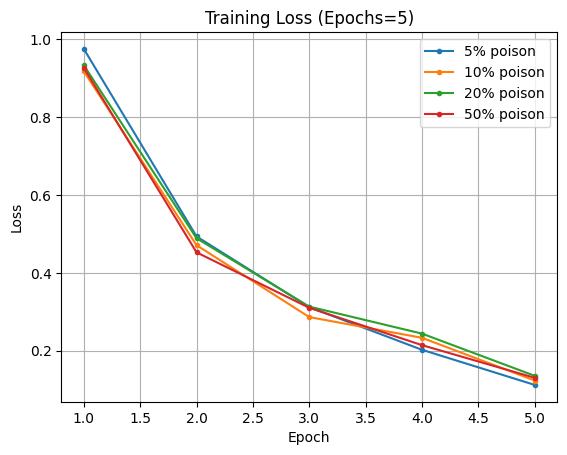

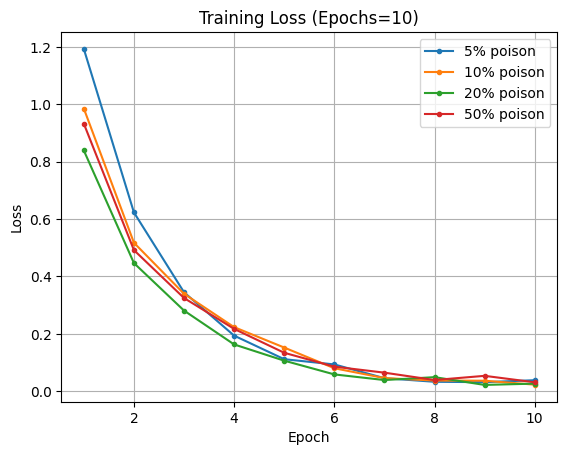

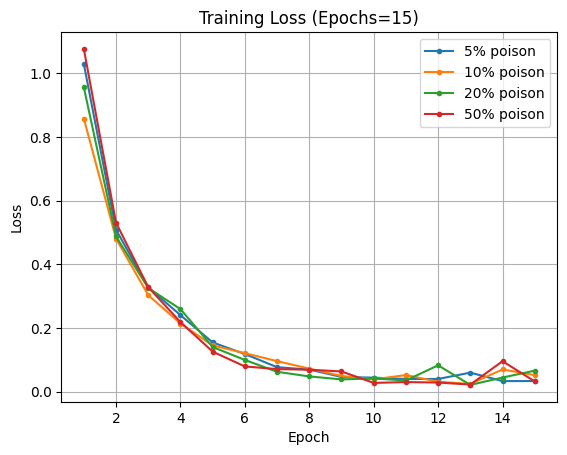

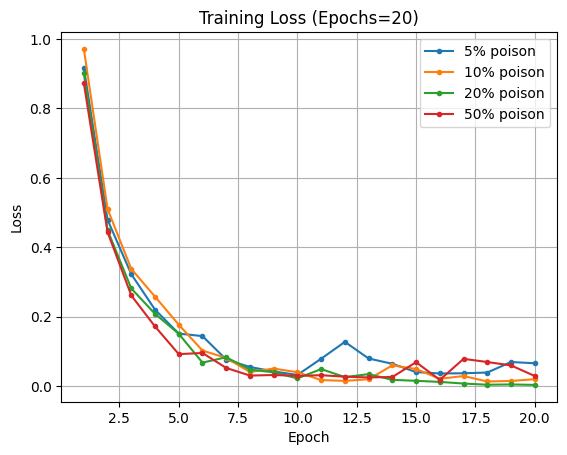

In [15]:
for i, epoch in enumerate(epochs_list):
    plt.figure()

    for j, ratio in enumerate(poison_ratios):
        losses = loss_results[i][j]
        plt.plot(range(1, len(losses)+1), losses, marker="o", markersize=3, label=f"{ratio*100:.0f}% poison")

    plt.title(f"Training Loss (Epochs={epoch})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

### Metric Tables

In [16]:
accuracy_table = []
precision_table = []
recall_table = []
f1_table = []

for i in range(len(epochs_list)):

    acc_row = []
    prec_row = []
    rec_row = []
    f1_row = []

    for j in range(len(poison_ratios)):

        report = report_results[i][j]

        acc_row.append(report["accuracy"])
        prec_row.append(report["Poison"]["precision"])
        rec_row.append(report["Poison"]["recall"])
        f1_row.append(report["Poison"]["f1-score"])

    accuracy_table.append(acc_row)
    precision_table.append(prec_row)
    recall_table.append(rec_row)
    f1_table.append(f1_row)

In [ ]:
columns = [f"{int(r*100)}%" for r in poison_ratios]
index = [f"{e} epochs" for e in epochs_list]

accuracy_df = pd.DataFrame(accuracy_table, index=index, columns=columns)
precision_df = pd.DataFrame(precision_table, index=index, columns=columns)
recall_df = pd.DataFrame(recall_table, index=index, columns=columns)
f1_df = pd.DataFrame(f1_table, index=index, columns=columns)

print("Accuracy")
print(accuracy_df)

print("\nPrecision")
print(precision_df)

print("\nRecall")
print(recall_df)

print("\nF1 Score")
print(f1_df)

Accuracy
             5%   10%   20%   50%
5 epochs   0.90  0.85  0.75  0.65
10 epochs  0.90  0.90  0.75  0.70
15 epochs  0.85  0.85  0.80  0.65
20 epochs  0.90  0.80  0.75  0.70

Precision
            5%  10%       20%       50%
5 epochs   0.0  0.0  0.400000  0.615385
10 epochs  0.0  0.5  0.000000  0.666667
15 epochs  0.0  0.0  0.000000  0.714286
20 epochs  0.0  0.0  0.333333  0.833333

Recall
            5%  10%   20%  50%
5 epochs   0.0  0.0  0.50  0.8
10 epochs  0.0  0.5  0.00  0.8
15 epochs  0.0  0.0  0.00  0.5
20 epochs  0.0  0.0  0.25  0.5

F1 Score
            5%  10%       20%       50%
5 epochs   0.0  0.0  0.444444  0.695652
10 epochs  0.0  0.5  0.000000  0.727273
15 epochs  0.0  0.0  0.000000  0.588235
20 epochs  0.0  0.0  0.285714  0.625000
